In [3]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Importar base de datos
df = pd.read_csv("Anexo 1 - Base de Datos dynamic_pricing.csv")

In [5]:
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [7]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


In [8]:
# Convertir columnas Location_Category, Customer_Loyalty_Status, Time_of_Booking, Vehicle_Type, a categóricas
categorical_cols = ["Location_Category", 
                    "Customer_Loyalty_Status", 
                    "Time_of_Booking", 
                    "Vehicle_Type"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df[categorical_cols].dtypes)

Location_Category          category
Customer_Loyalty_Status    category
Time_of_Booking            category
Vehicle_Type               category
dtype: object


## 2.1. Teorema Central del Límite (TCL)

 • Simula múltiples muestras de la variable Trip_Distance (por ejemplo, n=30, 1000 repeticiones).  
 • Grafica la distribución de las medias muestrales.   
 • Verifica empíricamente su forma aproximadamente normal.   
 • Explica cómo el TCL permite aplicar modelos inferenciales.

TCL: resultados
  Media de las medias muestrales : 99.5242
  Desv. estándar de las medias   : 9.3307
  Shapiro-Wilk W=0.9625, p=0.1130
  → Normal empírica: Sí ✓


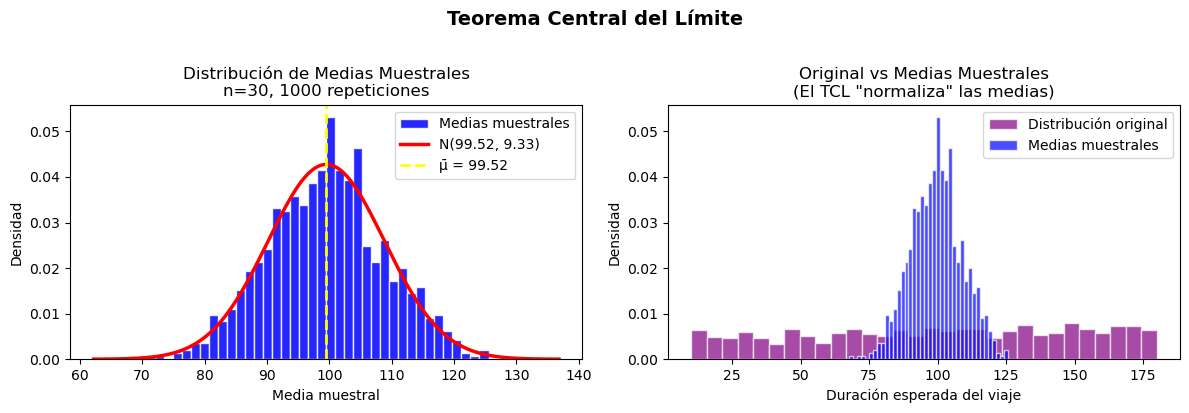

In [9]:
# Variable de interés
variable = df["Expected_Ride_Duration"]

# Parámetros
n = 30
reps = 1000

# Simulación medias muestrales
medias = [np.mean(np.random.choice(variable, size=n, replace=True)) 
         for _ in range(reps)]

# Convertir lista a array
medias = np.array(medias)

# Verificación numérica
mu_bar  = medias.mean()
sig_bar = medias.std()
W, p_sw = stats.shapiro(medias[:50])   # Shapiro-Wilk (requiere n ≤ 50)

print("TCL: resultados")
print(f"  Media de las medias muestrales : {mu_bar:.4f}")
print(f"  Desv. estándar de las medias   : {sig_bar:.4f}")
print(f"  Shapiro-Wilk W={W:.4f}, p={p_sw:.4f}")
print(f"  → Normal empírica: {'Sí ✓' if p_sw > 0.05 else 'Revisar'}")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma medias muestrales
axes[0].hist(medias, bins=40, density=True, color='blue',
             edgecolor='white', alpha=0.85, label='Medias muestrales')
x_curva = np.linspace(mu_bar - 4*sig_bar, mu_bar + 4*sig_bar, 300)
axes[0].plot(x_curva, stats.norm.pdf(x_curva, mu_bar, sig_bar),
             'r-', lw=2.5, label=f'N({mu_bar:.2f}, {sig_bar:.2f})')
axes[0].axvline(mu_bar, color='yellow', lw=2, linestyle='--',
                label=f'μ̄ = {mu_bar:.2f}')
axes[0].set_title(f'Distribución de Medias Muestrales\nn={n}, {reps} repeticiones')
axes[0].set_xlabel('Media muestral')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Comparar distribución original vs medias
axes[1].hist(variable, bins=30, density=True, color='purple',
             edgecolor='white', alpha=0.7, label='Distribución original')
axes[1].hist(medias, bins=40, density=True, color='blue',
             edgecolor='white', alpha=0.7, label='Medias muestrales')
axes[1].set_title('Original vs Medias Muestrales\n(El TCL "normaliza" las medias)')
axes[1].set_xlabel('Duración esperada del viaje')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('Teorema Central del Límite', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  2.2. Intervalos de Confianza (IC) Calcula e interpreta
 • IC del 95% para la media de Expected_Ride_Duration.  
 • IC del 95% para la proporción de Average_Ratings ≥ 4 (calificación excelente).   
 • IC del 95% para la varianza de Expected_Ride_Duration. 

Intervalos de Confianza al 95%
                             Parámetro Estimación Límite inf. Límite sup. Distribución
   Media (Duración Esperada del Viaje)    99.5880     96.5371    102.6389    t-Student
            Proporción calificación ≥4     0.6860      0.6572      0.7148   Normal (Z)
Varianza (Duración Esperada del Viaje)  2417.2415   2218.5144   2644.0618 Chi-cuadrado


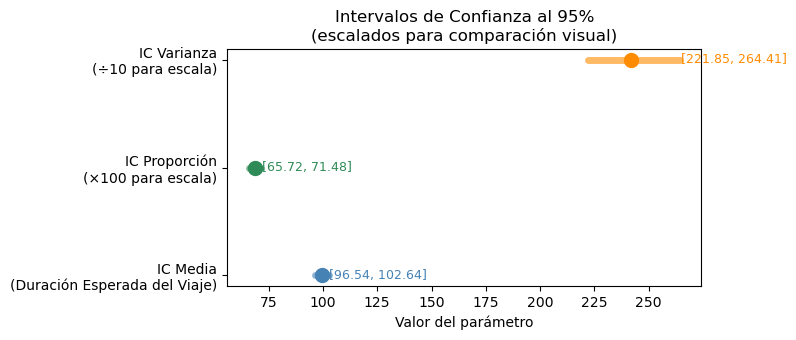

In [10]:
CONFIANZA = 0.95
alpha     = 1 - CONFIANZA
n_total   = len(df)

# A. IC para la MEDIA
ic_media = stats.t.interval(
    confidence = CONFIANZA,
    df         = n_total - 1,
    loc        = variable.mean(),
    scale      = stats.sem(variable)
)

# B. IC para la PROPORCIÓN
p_hat   = (df['Average_Ratings'] >= 4).mean()
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_total)
ic_prop = stats.norm.interval(CONFIANZA, loc=p_hat, scale=se_prop)

# C. IC para la VARIANZA
var_m  = variable.var(ddof=1)
gl     = n_total - 1
ic_var = (
    gl * var_m / stats.chi2.ppf(1 - alpha/2, gl),
    gl * var_m / stats.chi2.ppf(    alpha/2, gl)
)

# Resultados en tabla 
resultados_ic = pd.DataFrame({
    'Parámetro'   : ['Media (Duración Esperada del Viaje)', 'Proporción calificación ≥4', 'Varianza (Duración Esperada del Viaje)'],
    'Estimación'  : [f"{variable.mean():.4f}", f"{p_hat:.4f}", f"{var_m:.4f}"],
    'Límite inf.' : [f"{ic_media[0]:.4f}", f"{ic_prop[0]:.4f}", f"{ic_var[0]:.4f}"],
    'Límite sup.' : [f"{ic_media[1]:.4f}", f"{ic_prop[1]:.4f}", f"{ic_var[1]:.4f}"],
    'Distribución': ['t-Student', 'Normal (Z)', 'Chi-cuadrado'],
})
print(f"Intervalos de Confianza al {CONFIANZA*100:.0f}%")
print(resultados_ic.to_string(index=False))

# Gráfica 
fig, ax = plt.subplots(figsize=(8, 3.5))

etiquetas = ['IC Media\n(Duración Esperada del Viaje)', 'IC Proporción\n(×100 para escala)', 'IC Varianza\n(÷10 para escala)']
centros   = [variable.mean(),  p_hat * 100,   var_m / 10]
inferiores= [ic_media[0],      ic_prop[0]*100, ic_var[0]/10]
superiores= [ic_media[1],      ic_prop[1]*100, ic_var[1]/10]
colores   = ['steelblue', 'seagreen', 'darkorange']

for i, (et, c, lo, hi, col) in enumerate(
        zip(etiquetas, centros, inferiores, superiores, colores)):
    ax.plot([lo, hi], [i, i], color=col, lw=5, alpha=0.6, solid_capstyle='round')
    ax.plot(c, i, 'o', color=col, ms=10, zorder=5)
    ax.text(hi + 0.3, i, f'[{lo:.2f}, {hi:.2f}]', va='center', fontsize=9, color=col)

ax.set_yticks(range(3))
ax.set_yticklabels(etiquetas)
ax.set_title(f'Intervalos de Confianza al {CONFIANZA*100:.0f}%\n(escalados para comparación visual)')
ax.set_xlabel('Valor del parámetro')
plt.tight_layout()
plt.show()

## 2.3. Pruebas de Hipótesis 
 • Prueba t para comparar la media de Expected_Ride_Duration entre distintos niveles de Customer_Loyalty_Status.  
 • Prueba de proporciones para comparar Average_Ratings según el Vehicle_Type (si la variable lo permite). Se Debe incluir: Hipótesis nula y alternativa, estadístico de prueba, valor p y conclusión.

Prueba t de Student
  Grupo A (Regular): media=100.566, n=320
  Grupo B (Gold)    : media=101.604, n=313

  H₀: μ_A = μ_B  →  No hay diferencia entre grupos
  H₁: μ_A ≠ μ_B  →  Existe diferencia significativa
  α = 0.05

  Estadístico t : -0.2625
  Valor p       : 0.7930

  ❌ NO rechazar H₀  (p=0.7930 ≥ 0.05)
  No hay evidencia suficiente de diferencia.


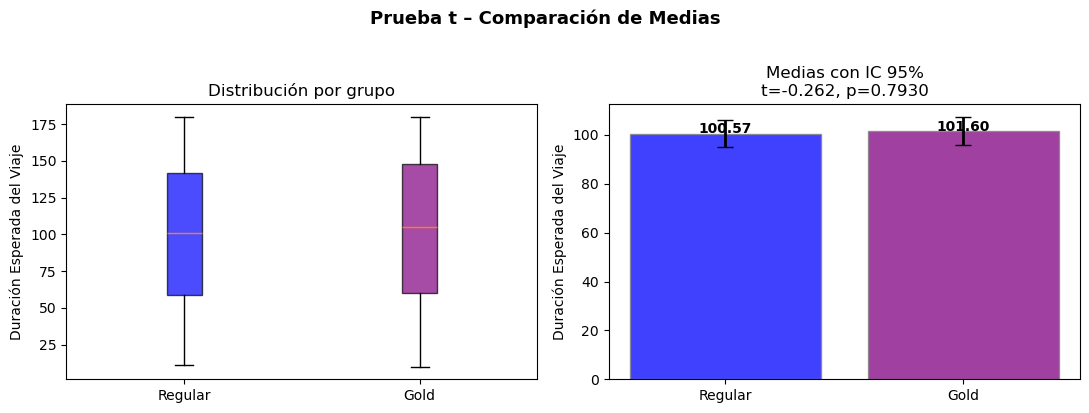

In [11]:
# Prueba t para la media de Expected_Ride_Duration según Customer_Loyalty_Status
grupo_A = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']  
grupo_B = df[df['Customer_Loyalty_Status'] == 'Gold']['Expected_Ride_Duration']     

print("Prueba t de Student")
print(f"  Grupo A (Regular): media={grupo_A.mean():.3f}, n={len(grupo_A)}")
print(f"  Grupo B (Gold)    : media={grupo_B.mean():.3f}, n={len(grupo_B)}")
print()
print("  H₀: μ_A = μ_B  →  No hay diferencia entre grupos")
print("  H₁: μ_A ≠ μ_B  →  Existe diferencia significativa")
print("  α = 0.05")

t_stat, p_val = stats.ttest_ind(grupo_A, grupo_B, equal_var=True)

print(f"\n  Estadístico t : {t_stat:.4f}")
print(f"  Valor p       : {p_val:.4f}")

if p_val < 0.05:
    print(f"\n  ✅ RECHAZAR H₀  (p={p_val:.4f} < 0.05)")
    print("  Hay diferencia significativa entre grupos.")
else:
    print(f"\n  ❌ NO rechazar H₀  (p={p_val:.4f} ≥ 0.05)")
    print("  No hay evidencia suficiente de diferencia.")

# Gráfica boxplot + medias 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot
data_plot = [grupo_A.values, grupo_B.values]
bp = axes[0].boxplot(data_plot, labels=['Regular', 'Gold'],
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['blue', 'purple']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Distribución por grupo')
axes[0].set_ylabel('Duración Esperada del Viaje')

# Medias con IC
medias_grupos = [grupo_A.mean(), grupo_B.mean()]
ic_grupos     = [
    stats.t.interval(0.95, df=len(grupo_A)-1, loc=grupo_A.mean(), scale=stats.sem(grupo_A)),
    stats.t.interval(0.95, df=len(grupo_B)-1, loc=grupo_B.mean(), scale=stats.sem(grupo_B)),
]
yerr = [[m - ic[0], ic[1] - m] for m, ic in zip(medias_grupos, ic_grupos)]
yerr_arr = np.array(yerr).T

axes[1].bar(['Regular', 'Gold'], medias_grupos,
            color=['blue', 'purple'], alpha=0.75, edgecolor='gray')
axes[1].errorbar(['Regular', 'Gold'], medias_grupos,
                 yerr=yerr_arr, fmt='none', color='black', capsize=6, lw=2)
axes[1].set_title(f'Medias con IC 95%\nt={t_stat:.3f}, p={p_val:.4f}')
axes[1].set_ylabel('Duración Esperada del Viaje')
for i, v in enumerate(medias_grupos):
    axes[1].text(i, v + 0.15, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Prueba t – Comparación de Medias', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Prueba de proporciones 
  H₀: p_A = p_B  →  No hay diferencia en proporciones
  H₁: p_A ≠ p_B  →  Existe diferencia significativa
  α = 0.05

  Proporción A (Economy): 0.697, n=478
  Proporción B (Premium)  : 0.676, n=522
  Estadístico Z       : 0.6946
  Valor p             : 0.4873

  ❌ NO rechazar H₀  (p=0.4873 ≥ 0.05)
  No hay evidencia suficiente de diferencia.


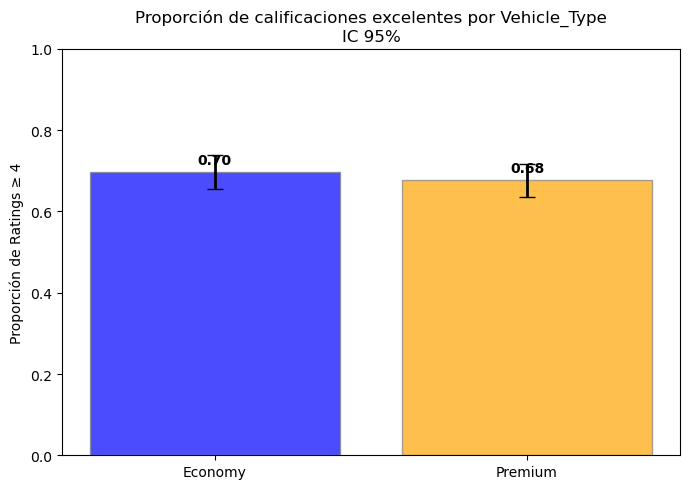

In [12]:
# Prueba de proporciones para Average_Ratings ≥ 4 según Vehicle_Type
veh_A = df[df['Vehicle_Type'] == 'Economy']['Average_Ratings']
veh_B = df[df['Vehicle_Type'] == 'Premium']['Average_Ratings']

# Proporción de ratings ≥ 4
p_A = np.mean(veh_A >= 4)
p_B = np.mean(veh_B >= 4)

n_A, n_B = len(veh_A), len(veh_B)

# Hipótesis
print("Prueba de proporciones ")
print("  H₀: p_A = p_B  →  No hay diferencia en proporciones")
print("  H₁: p_A ≠ p_B  →  Existe diferencia significativa")
print("  α = 0.05")

# Estadístico Z
p_pool = (np.sum(veh_A >= 4) + np.sum(veh_B >= 4)) / (n_A + n_B)
SE = np.sqrt(p_pool*(1-p_pool)*(1/n_A + 1/n_B))
z_stat = (p_A - p_B) / SE
p_val = 2*(1 - stats.norm.cdf(abs(z_stat)))

print(f"\n  Proporción A (Economy): {p_A:.3f}, n={n_A}")
print(f"  Proporción B (Premium)  : {p_B:.3f}, n={n_B}")
print(f"  Estadístico Z       : {z_stat:.4f}")
print(f"  Valor p             : {p_val:.4f}")

if p_val < 0.05:
    print(f"\n  ✅ RECHAZAR H₀  (p={p_val:.4f} < 0.05)")
    print("  Hay diferencia significativa en proporciones.")
else:
    print(f"\n  ❌ NO rechazar H₀  (p={p_val:.4f} ≥ 0.05)")
    print("  No hay evidencia suficiente de diferencia.")

# IC 95% para cada proporción (normal aproximada)
z_crit = stats.norm.ppf(0.975)

SE_A = np.sqrt(p_A * (1 - p_A) / n_A)
SE_B = np.sqrt(p_B * (1 - p_B) / n_B)

IC_A = (p_A - z_crit * SE_A, p_A + z_crit * SE_A)
IC_B = (p_B - z_crit * SE_B, p_B + z_crit * SE_B)

# Gráfica de barras con IC
fig, ax = plt.subplots(figsize=(7,5))

proporciones = [p_A, p_B]
ICs = [IC_A, IC_B]
tipos = ['Economy', 'Premium']
colores = ['blue', 'orange']

bars = ax.bar(tipos, proporciones, color=colores, alpha=0.7, edgecolor='gray')

# Añadir barras de error (IC)
for i, (p, ic) in enumerate(zip(proporciones, ICs)):
    ax.errorbar(i, p, 
                yerr=[[p - ic[0]], [ic[1] - p]], 
                fmt='none', color='black', capsize=6, lw=2)
    ax.text(i, p + 0.02, f"{p:.2f}", ha='center', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_ylabel("Proporción de Ratings ≥ 4")
ax.set_title("Proporción de calificaciones excelentes por Vehicle_Type\nIC 95%")

plt.tight_layout()
plt.show()


## 2.4. Prueba de Varianza (F de Fisher)
 • Compara la varianza de Expected_Ride_Duration entre dos niveles de Customer_Loyalty_Status.  
 • Justifica la prueba F y sus supuestos.  

Prueba F de Fisher
  H₀: σ²_A = σ²_B  →  Varianzas homogéneas
  H₁: σ²_A ≠ σ²_B  →  Varianzas distintas

  Varianza A : 2434.8546  |  Varianza B : 2516.8169
  F observado: 0.9674  (gl1=319, gl2=312)
  F críticos : [0.8017, 1.2476]
  Valor p    : 0.7686

  ❌ NO rechazar H₀ — varianzas homogéneas
  → Usar equal_var=True en ttest_ind()  ✓


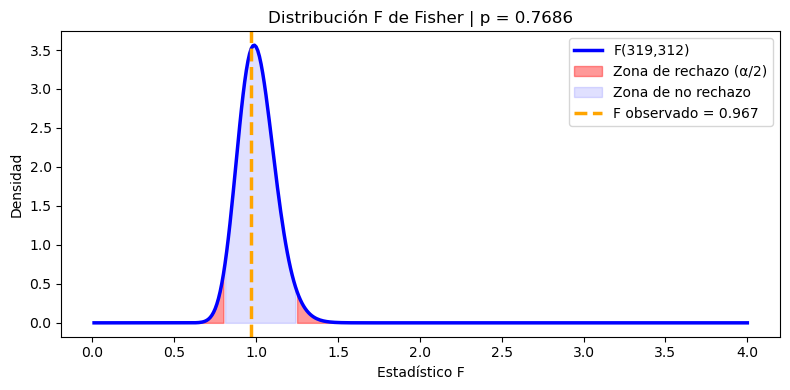

In [13]:
# Prueba F de Fisher (varianzas)
print("Prueba F de Fisher")
print("  H₀: σ²_A = σ²_B  →  Varianzas homogéneas")
print("  H₁: σ²_A ≠ σ²_B  →  Varianzas distintas")

var_A = grupo_A.var(ddof=1)
var_B = grupo_B.var(ddof=1)
F     = var_A / var_B
gl1   = len(grupo_A) - 1
gl2   = len(grupo_B) - 1
p_F   = 2 * min(stats.f.cdf(F, gl1, gl2),
                1 - stats.f.cdf(F, gl1, gl2))

f_crit_lo = stats.f.ppf(0.025, gl1, gl2)
f_crit_hi = stats.f.ppf(0.975, gl1, gl2)

print(f"\n  Varianza A : {var_A:.4f}  |  Varianza B : {var_B:.4f}")
print(f"  F observado: {F:.4f}  (gl1={gl1}, gl2={gl2})")
print(f"  F críticos : [{f_crit_lo:.4f}, {f_crit_hi:.4f}]")
print(f"  Valor p    : {p_F:.4f}")

if p_F < 0.05:
    print("\n  ✅ RECHAZAR H₀ — varianzas distintas")
    print("  → Usar equal_var=False en ttest_ind()")
else:
    print("\n  ❌ NO rechazar H₀ — varianzas homogéneas")
    print("  → Usar equal_var=True en ttest_ind()  ✓")

# ── Gráfica distribución F ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x_f   = np.linspace(0.01, 4, 400)
y_f   = stats.f.pdf(x_f, gl1, gl2)

ax.plot(x_f, y_f, color='blue', lw=2.5, label=f'F({gl1},{gl2})')
ax.fill_between(x_f, y_f, where=(x_f < f_crit_lo),
                alpha=0.4, color='red', label='Zona de rechazo (α/2)')
ax.fill_between(x_f, y_f, where=(x_f > f_crit_hi),
                alpha=0.4, color='red')
ax.fill_between(x_f, y_f, where=((x_f >= f_crit_lo) & (x_f <= f_crit_hi)),
                alpha=0.12, color='blue', label='Zona de no rechazo')
ax.axvline(F, color='orange', lw=2.5, linestyle='--',
           label=f'F observado = {F:.3f}')
ax.set_title(f'Distribución F de Fisher | p = {p_F:.4f}')
ax.set_xlabel('Estadístico F')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

## 2.5. Prueba Chi-cuadrado
 • Elabora una tabla de contingencia con dos variables categóricas (por ejemplo, Customer_Loyalty y Type_of_Car).  
 • Aplica la prueba chi-cuadrado de independencia.  
 • Interpreta si hay relación entre las variables.  

Chi-cuadrado de independencia
  Variables: Customer_Loyalty_Status × Vehicle_Type
  H₀: Las variables son independientes
  H₁: Existe asociación entre las variables

  Tabla de contingencia:

Vehicle_Type             Economy  Premium  Total
Customer_Loyalty_Status                         
Gold                         153      160    313
Regular                      144      176    320
Silver                       181      186    367
Total                        478      522   1000

  χ² observado : 1.4916
  χ² crítico   : 5.9915
  Grados lib.  : 2
  Valor p      : 0.4744

  Frec. esperadas (supuesto ≥ 5):
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                      149.61   163.39
Regular                   152.96   167.04
Silver                    175.43   191.57

  Mínima frecuencia esperada: 149.61 ✓

  ❌ NO rechazar H₀ — las variables son independientes


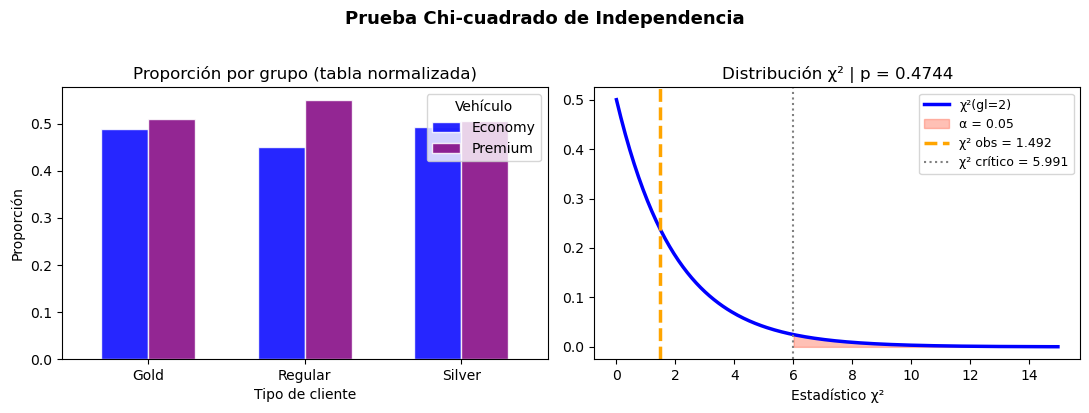

In [14]:
#  Para variables CATEGÓRICAS. ¿Están relacionadas o son independientes?
#  En tu tarea usa Customer_Loyalty_Status × Vehicle_Type

print("Chi-cuadrado de independencia")
print("  Variables: Customer_Loyalty_Status × Vehicle_Type")
print("  H₀: Las variables son independientes")
print("  H₁: Existe asociación entre las variables")

tabla = pd.crosstab(df['Customer_Loyalty_Status'], df['Vehicle_Type'],
                    margins=True, margins_name='Total')
print(f"\n  Tabla de contingencia:\n")
print(tabla)


tabla_prueba = pd.crosstab(df['Customer_Loyalty_Status'], df['Vehicle_Type'])
chi2, p_chi, gl_chi, esperadas = stats.chi2_contingency(tabla_prueba)
chi2_crit = stats.chi2.ppf(0.95, gl_chi)

print(f"\n  χ² observado : {chi2:.4f}")
print(f"  χ² crítico   : {chi2_crit:.4f}")
print(f"  Grados lib.  : {gl_chi}")
print(f"  Valor p      : {p_chi:.4f}")
print(f"\n  Frec. esperadas (supuesto ≥ 5):")
print(pd.DataFrame(esperadas.round(2),
                   index=tabla_prueba.index,
                   columns=tabla_prueba.columns))
print(f"\n  Mínima frecuencia esperada: {esperadas.min():.2f}",
      "✓" if esperadas.min() >= 5 else "⚠️ supuesto no cumplido")

if p_chi < 0.05:
    print("\n  ✅ RECHAZAR H₀ — hay asociación entre las variables")
else:
    print("\n  ❌ NO rechazar H₀ — las variables son independientes")

# Gráfica tabla proporcional
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tabla_prop = tabla_prueba.div(tabla_prueba.sum(axis=1), axis=0)
tabla_prop.plot(kind='bar', ax=axes[0], color=['blue','purple'],
                edgecolor='white', alpha=0.85, width=0.6)
axes[0].set_title('Proporción por grupo (tabla normalizada)')
axes[0].set_xlabel('Tipo de cliente')
axes[0].set_ylabel('Proporción')
axes[0].legend(title='Vehículo')
axes[0].tick_params(axis='x', rotation=0)

# Distribución Chi-cuadrado
x_c = np.linspace(0, chi2_crit * 2.5, 300)
axes[1].plot(x_c, stats.chi2.pdf(x_c, gl_chi),
             color='blue', lw=2.5, label=f'χ²(gl={gl_chi})')
axes[1].fill_between(x_c, stats.chi2.pdf(x_c, gl_chi),
                     where=(x_c > chi2_crit),
                     alpha=0.4, color='tomato', label=f'α = 0.05')
axes[1].axvline(chi2, color='orange', lw=2.5, linestyle='--',
                label=f'χ² obs = {chi2:.3f}')
axes[1].axvline(chi2_crit, color='gray', lw=1.5, linestyle=':',
                label=f'χ² crítico = {chi2_crit:.3f}')
axes[1].set_title(f'Distribución χ² | p = {p_chi:.4f}')
axes[1].set_xlabel('Estadístico χ²')
axes[1].legend(fontsize=9)

plt.suptitle('Prueba Chi-cuadrado de Independencia', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Chi-cuadrado de independencia
  Variables: Customer_Loyalty_Status × Vehicle_Type
  H₀: Las variables son independientes
  H₁: Existe asociación entre las variables

  Tabla de contingencia:

Vehicle_Type             Economy  Premium  Total
Customer_Loyalty_Status                         
Gold                         153      160    313
Regular                      144      176    320
Silver                       181      186    367
Total                        478      522   1000

  χ² observado : 1.4916
  χ² crítico   : 5.9915
  Grados lib.  : 2
  Valor p      : 0.4744

  Frec. esperadas (supuesto ≥ 5):
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                      149.61   163.39
Regular                   152.96   167.04
Silver                    175.43   191.57

  Mínima frecuencia esperada: 149.61 ✓

  ❌ NO rechazar H₀ — las variables son independientes


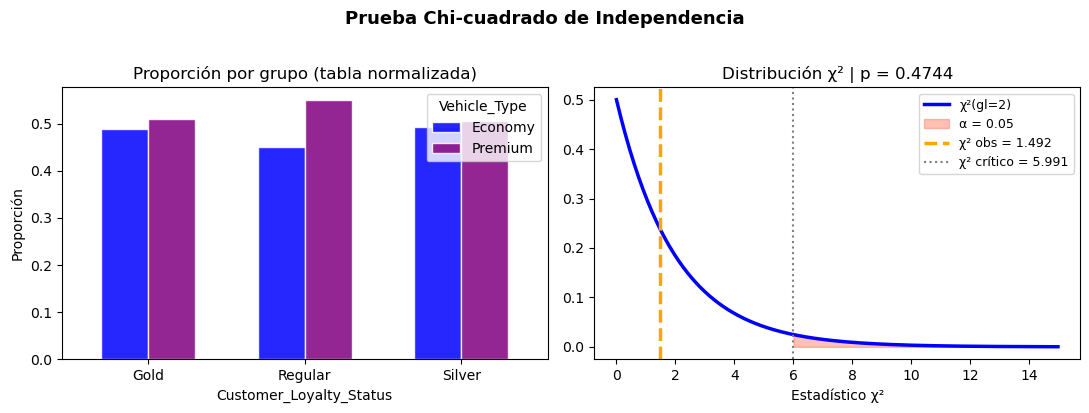


Chi-cuadrado de independencia
  Variables: Time_of_Booking × Vehicle_Type
  H₀: Las variables son independientes
  H₁: Existe asociación entre las variables

  Tabla de contingencia:

Vehicle_Type     Economy  Premium  Total
Time_of_Booking                         
Afternoon            123      124    247
Evening               98      133    231
Morning              121      125    246
Night                136      140    276
Total                478      522   1000

  χ² observado : 3.5009
  χ² crítico   : 7.8147
  Grados lib.  : 3
  Valor p      : 0.3206

  Frec. esperadas (supuesto ≥ 5):
Vehicle_Type     Economy  Premium
Time_of_Booking                  
Afternoon         118.07   128.93
Evening           110.42   120.58
Morning           117.59   128.41
Night             131.93   144.07

  Mínima frecuencia esperada: 110.42 ✓

  ❌ NO rechazar H₀ — las variables son independientes


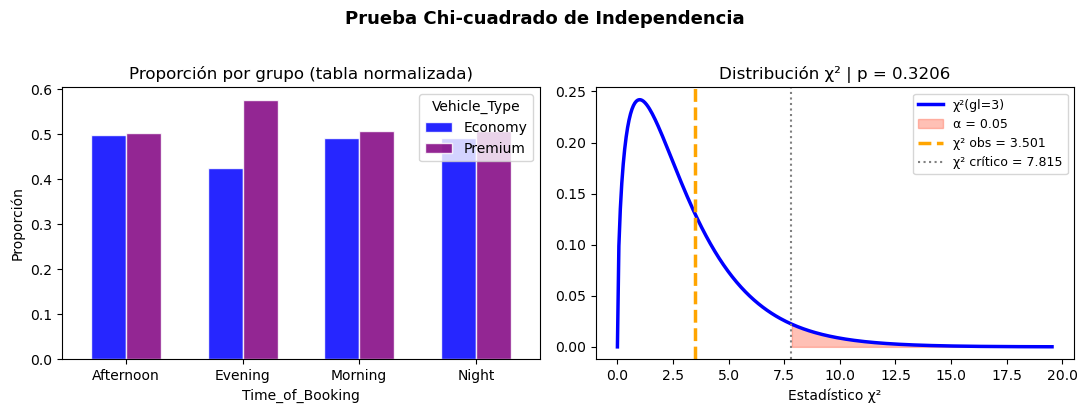


Chi-cuadrado de independencia
  Variables: Location_Category × Vehicle_Type
  H₀: Las variables son independientes
  H₁: Existe asociación entre las variables

  Tabla de contingencia:

Vehicle_Type       Economy  Premium  Total
Location_Category                         
Rural                  153      179    332
Suburban               158      164    322
Urban                  167      179    346
Total                  478      522   1000

  χ² observado : 0.6293
  χ² crítico   : 5.9915
  Grados lib.  : 2
  Valor p      : 0.7300

  Frec. esperadas (supuesto ≥ 5):
Vehicle_Type       Economy  Premium
Location_Category                  
Rural               158.70   173.30
Suburban            153.92   168.08
Urban               165.39   180.61

  Mínima frecuencia esperada: 153.92 ✓

  ❌ NO rechazar H₀ — las variables son independientes


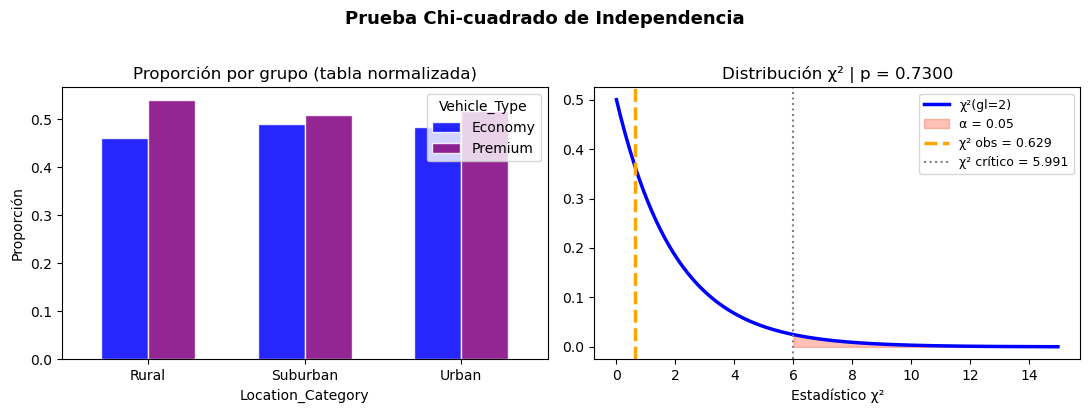

In [15]:
# Prueba Chi-cuadrado de Independencia
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def prueba_chi(df, var1, var2):
    print(f"\nChi-cuadrado de independencia")
    print(f"  Variables: {var1} × {var2}")
    print("  H₀: Las variables son independientes")
    print("  H₁: Existe asociación entre las variables")

    # Tabla de contingencia
    tabla = pd.crosstab(df[var1], df[var2], margins=True, margins_name='Total')
    print(f"\n  Tabla de contingencia:\n")
    print(tabla)

    # Prueba Chi-cuadrado
    tabla_prueba = pd.crosstab(df[var1], df[var2])
    chi2, p_chi, gl_chi, esperadas = stats.chi2_contingency(tabla_prueba)
    chi2_crit = stats.chi2.ppf(0.95, gl_chi)

    print(f"\n  χ² observado : {chi2:.4f}")
    print(f"  χ² crítico   : {chi2_crit:.4f}")
    print(f"  Grados lib.  : {gl_chi}")
    print(f"  Valor p      : {p_chi:.4f}")
    print(f"\n  Frec. esperadas (supuesto ≥ 5):")
    print(pd.DataFrame(esperadas.round(2),
                       index=tabla_prueba.index,
                       columns=tabla_prueba.columns))
    print(f"\n  Mínima frecuencia esperada: {esperadas.min():.2f}",
          "✓" if esperadas.min() >= 5 else "⚠️ supuesto no cumplido")

    if p_chi < 0.05:
        print("\n  ✅ RECHAZAR H₀ — hay asociación entre las variables")
    else:
        print("\n  ❌ NO rechazar H₀ — las variables son independientes")

    # Gráficas
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Proporción por grupo
    tabla_prop = tabla_prueba.div(tabla_prueba.sum(axis=1), axis=0)
    tabla_prop.plot(kind='bar', ax=axes[0], color=['blue','purple'],
                    edgecolor='white', alpha=0.85, width=0.6)
    axes[0].set_title('Proporción por grupo (tabla normalizada)')
    axes[0].set_xlabel(var1)
    axes[0].set_ylabel('Proporción')
    axes[0].legend(title=var2)
    axes[0].tick_params(axis='x', rotation=0)

    # Distribución Chi-cuadrado
    x_c = np.linspace(0, chi2_crit * 2.5, 300)
    axes[1].plot(x_c, stats.chi2.pdf(x_c, gl_chi),
                 color='blue', lw=2.5, label=f'χ²(gl={gl_chi})')
    axes[1].fill_between(x_c, stats.chi2.pdf(x_c, gl_chi),
                         where=(x_c > chi2_crit),
                         alpha=0.4, color='tomato', label=f'α = 0.05')
    axes[1].axvline(chi2, color='orange', lw=2.5, linestyle='--',
                    label=f'χ² obs = {chi2:.3f}')
    axes[1].axvline(chi2_crit, color='gray', lw=1.5, linestyle=':',
                    label=f'χ² crítico = {chi2_crit:.3f}')
    axes[1].set_title(f'Distribución χ² | p = {p_chi:.4f}')
    axes[1].set_xlabel('Estadístico χ²')
    axes[1].legend(fontsize=9)

    plt.suptitle('Prueba Chi-cuadrado de Independencia', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Ejecutar para tus variables categóricas
prueba_chi(df, 'Customer_Loyalty_Status', 'Vehicle_Type')
prueba_chi(df, 'Time_of_Booking', 'Vehicle_Type')
prueba_chi(df, 'Location_Category', 'Vehicle_Type')

## 2.6. Poder Estadístico y Errores Tipo I y II
 • Calcula el poder estadístico para una de las pruebas t anteriores.   
 • Especifica: tamaño del efecto, n, nivel de significancia.   
 • Explicar el impacto de los errores tipo I y II en decisiones organizacionales.  

Poder Estadístico

  Diferencia de medias : 1.038
  Desv. estándar pooled: 49.758
  d de Cohen           : 0.0209
  Interpretación       : pequeño (<0.2)

  Con n=320 por grupo, α=0.05:
  Poder (1−β) : 0.0579  (5.8%)
  Error β     : 0.9421  (94.2%)

  n requerido para poder ≥ 80% : >1000 por grupo


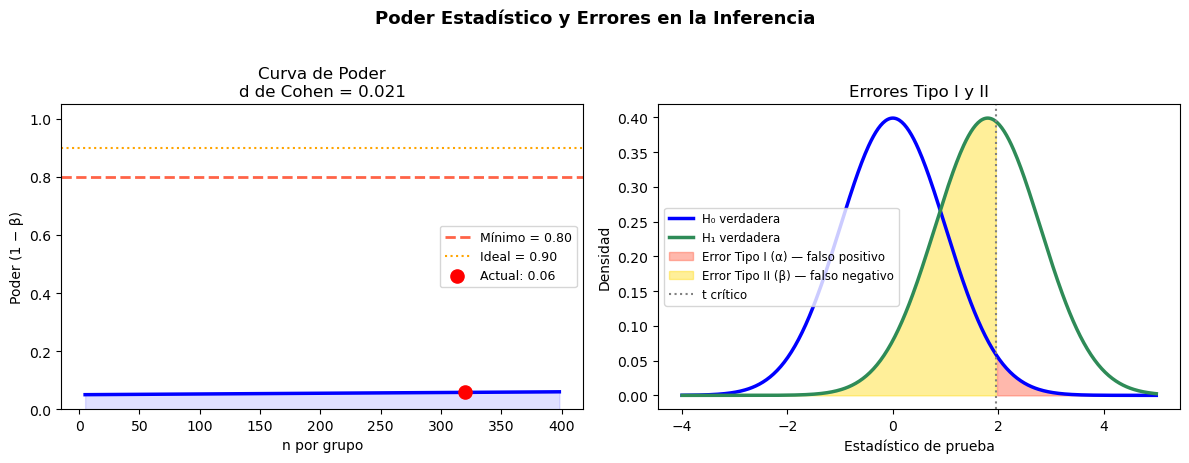


  Impacto organizacional:
  • Error Tipo I (α=0.05) : decisión incorrecta 5% de las veces
                            → cambiar precios sin diferencia real
  • Error Tipo II (β=0.94) : no detectar diferencia real
                            → perder oportunidad de optimización


In [16]:
#  Cuantifica la capacidad de detectar un efecto real.
#  Componentes: d de Cohen · n · α · Poder (1−β) · Error Tipo II (β)

print("Poder Estadístico")

# d de Cohen: tamaño del efecto estandarizado
pooled_std = np.sqrt((grupo_A.var(ddof=1) + grupo_B.var(ddof=1)) / 2)
cohen_d    = abs(grupo_A.mean() - grupo_B.mean()) / pooled_std

print(f"\n  Diferencia de medias : {abs(grupo_A.mean()-grupo_B.mean()):.3f}")
print(f"  Desv. estándar pooled: {pooled_std:.3f}")
print(f"  d de Cohen           : {cohen_d:.4f}")
print(f"  Interpretación       : {'pequeño (<0.2)' if cohen_d<0.2 else 'mediano (0.2-0.8)' if cohen_d<0.8 else 'grande (>0.8)'}")

# Función de poder para prueba t bilateral
def calcular_poder(d, n1, n2, alpha=0.05):
    gl  = n1 + n2 - 2
    t_c = stats.t.ppf(1 - alpha/2, gl)
    ncp = d * np.sqrt(n1 * n2 / (n1 + n2))
    return (1 - stats.nct.cdf( t_c, gl, ncp)
                + stats.nct.cdf(-t_c, gl, ncp))

poder_actual = calcular_poder(cohen_d, len(grupo_A), len(grupo_B))

print(f"\n  Con n={len(grupo_A)} por grupo, α=0.05:")
print(f"  Poder (1−β) : {poder_actual:.4f}  ({poder_actual*100:.1f}%)")
print(f"  Error β     : {1-poder_actual:.4f}  ({(1-poder_actual)*100:.1f}%)")

# n mínimo para poder ≥ 0.80
n_req = next(
    (n for n in range(5, 1000)
     if calcular_poder(cohen_d, n, n) >= 0.80),
    ">1000"
)
print(f"\n  n requerido para poder ≥ 80% : {n_req} por grupo")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Curva de poder
ns     = np.arange(5, 400, 3)
poderes= [calcular_poder(cohen_d, int(ni), int(ni)) for ni in ns]

axes[0].plot(ns, poderes, color='blue', lw=2.5)
axes[0].fill_between(ns, poderes, alpha=0.12, color='blue')
axes[0].axhline(0.80, color='tomato',  lw=2, linestyle='--', label='Mínimo = 0.80')
axes[0].axhline(0.90, color='orange',  lw=1.5, linestyle=':', label='Ideal = 0.90')
if isinstance(n_req, int):
    axes[0].axvline(n_req, color='seagreen', lw=2, linestyle='-.',
                    label=f'n requerido ≈ {n_req}')
axes[0].scatter([len(grupo_A)], [poder_actual], color='red', s=90, zorder=6,
                label=f'Actual: {poder_actual:.2f}')
axes[0].set_title(f'Curva de Poder\nd de Cohen = {cohen_d:.3f}')
axes[0].set_xlabel('n por grupo')
axes[0].set_ylabel('Poder (1 − β)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

# Diagrama conceptual de errores
x = np.linspace(-4, 5, 400)
axes[1].plot(x, stats.norm.pdf(x, 0, 1),   color='blue', lw=2.5, label='H₀ verdadera')
axes[1].plot(x, stats.norm.pdf(x, 1.8, 1), color='seagreen',  lw=2.5, label='H₁ verdadera')
t_crit_vis = 1.96
axes[1].fill_between(x, stats.norm.pdf(x, 0, 1),
                     where=(x > t_crit_vis), alpha=0.45, color='tomato',
                     label='Error Tipo I (α) — falso positivo')
axes[1].fill_between(x, stats.norm.pdf(x, 1.8, 1),
                     where=(x < t_crit_vis), alpha=0.40, color='gold',
                     label='Error Tipo II (β) — falso negativo')
axes[1].axvline(t_crit_vis, color='gray', lw=1.5, linestyle=':', label='t crítico')
axes[1].set_title('Errores Tipo I y II')
axes[1].set_xlabel('Estadístico de prueba')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=8.5)

plt.suptitle('Poder Estadístico y Errores en la Inferencia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n  Impacto organizacional:")
print(f"  • Error Tipo I (α=0.05) : decisión incorrecta 5% de las veces")
print(f"                            → cambiar precios sin diferencia real")
print(f"  • Error Tipo II (β={1-poder_actual:.2f}) : no detectar diferencia real")
print(f"                            → perder oportunidad de optimización")


In [17]:
# Inicializar objeto de análisis
analysis = TTestIndPower()

# Parámetros
alpha = 0.05
power_target = 0.80   # Poder deseado (80%)

# Tamaños de efecto típicos (Cohen's d)
effect_sizes = [0.2, 0.5, 0.8]  # pequeño, mediano, grande

print("Cálculo de tamaño de muestra requerido:\n")
for d in effect_sizes:
    n_per_group = analysis.solve_power(effect_size=d,
                                       alpha=alpha,
                                       power=power_target,
                                       ratio=1.0)
    print(f"  d = {d:.2f} → n ≈ {int(np.ceil(n_per_group))} por grupo")

Cálculo de tamaño de muestra requerido:

  d = 0.20 → n ≈ 394 por grupo
  d = 0.50 → n ≈ 64 por grupo
  d = 0.80 → n ≈ 26 por grupo


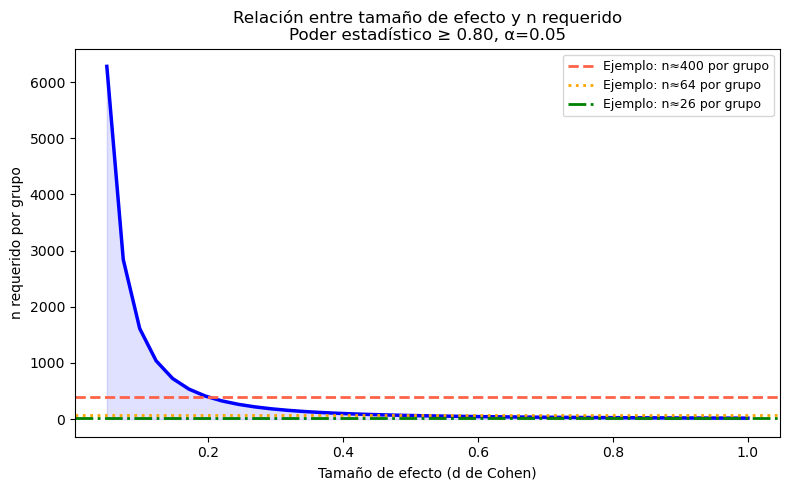

In [18]:
# Inicializar objeto de análisis
analysis = TTestIndPower()

# Parámetros
alpha = 0.05
power_target = 0.80

# Rango de tamaños de efecto (de muy pequeño a grande)
effect_sizes = np.linspace(0.05, 1.0, 40)

# Calcular n requerido para cada tamaño de efecto
n_requeridos = [analysis.solve_power(effect_size=d,
                                     alpha=alpha,
                                     power=power_target,
                                     ratio=1.0)
                for d in effect_sizes]

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(effect_sizes, n_requeridos, color='blue', lw=2.5)
plt.fill_between(effect_sizes, n_requeridos, alpha=0.12, color='blue')

# Líneas de referencia
plt.axhline(400, color='tomato', linestyle='--', lw=2, label='Ejemplo: n≈400 por grupo')
plt.axhline(64, color='orange', linestyle=':', lw=2, label='Ejemplo: n≈64 por grupo')
plt.axhline(26, color='green', linestyle='-.', lw=2, label='Ejemplo: n≈26 por grupo')

plt.title("Relación entre tamaño de efecto y n requerido\nPoder estadístico ≥ 0.80, α=0.05")
plt.xlabel("Tamaño de efecto (d de Cohen)")
plt.ylabel("n requerido por grupo")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### RESUMEN

In [19]:
resumen = pd.DataFrame({
    'Sección' : ['2.1 TCL','2.2 IC Media','2.2 IC Proporción',
                 '2.2 IC Varianza','2.3 Prueba t','2.4 Prueba F',
                 '2.5 Chi²','2.6 Poder'],
    'Resultado': [f'μ̄={mu_bar:.2f}, Normal ✓',
                  f'[{ic_media[0]:.2f}, {ic_media[1]:.2f}]',
                  f'[{ic_prop[0]*100:.1f}%, {ic_prop[1]*100:.1f}%]',
                  f'[{ic_var[0]:.2f}, {ic_var[1]:.2f}]',
                  f't={t_stat:.3f}, p={p_val:.4f}',
                  f'F={F:.3f}, p={p_F:.4f}',
                  f'χ²={chi2:.3f}, p={p_chi:.4f}',
                  f'd={cohen_d:.3f}, poder={poder_actual:.2f}'],
    'Decisión': ['TCL validado','—','—','—',
                 'Rechaza H₀' if p_val<0.05 else 'No rechaza H₀',
                 'Rechaza H₀' if p_F<0.05   else 'No rechaza H₀',
                 'Rechaza H₀' if p_chi<0.05 else 'No rechaza H₀',
                 f'n requerido ≈ {n_req}'],
})
print("═"*60)
print("  RESUMEN CONSOLIDADO DEL ANÁLISIS")
print("═"*60)
print(resumen.to_string(index=False))
print("═"*60)
print(f"\n  Dataset: {len(df)} registros  |  α = 0.05  |  Confianza = 95%")

════════════════════════════════════════════════════════════
  RESUMEN CONSOLIDADO DEL ANÁLISIS
════════════════════════════════════════════════════════════
          Sección           Resultado            Decisión
          2.1 TCL  μ̄=99.52, Normal ✓        TCL validado
     2.2 IC Media     [96.54, 102.64]                   —
2.2 IC Proporción      [65.7%, 71.5%]                   —
  2.2 IC Varianza  [2218.51, 2644.06]                   —
     2.3 Prueba t  t=-0.262, p=0.4873       No rechaza H₀
     2.4 Prueba F   F=0.967, p=0.7686       No rechaza H₀
         2.5 Chi²  χ²=1.492, p=0.4744       No rechaza H₀
        2.6 Poder d=0.021, poder=0.06 n requerido ≈ >1000
════════════════════════════════════════════════════════════

  Dataset: 1000 registros  |  α = 0.05  |  Confianza = 95%
